In [65]:
import pandas as pd
import os
import glob

RAW_PATH = r"D:\CricMetric-AI\data\raw\odis"

files = glob.glob(os.path.join(RAW_PATH, "*.csv"))
print(f"Total match files found: {len(files)}")

Total match files found: 2544


In [66]:
with open(files[0], 'r') as f:
    for i, line in enumerate(f):
        if i >= 74:
            print(f"Line {i}: {line.strip()}")
        if i > 85:
            break

Line 74: info,registry,people,TM Head,12b610c2
Line 75: info,registry,people,Umar Akmal,fd2bf2a0
Line 76: info,registry,people,Wahab Riaz,b3118300
Line 77: ball,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,,,,"","",0.1,,,,
Line 78: ball,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,,,,"","",0.2,,,,
Line 79: ball,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,,,,"","",0.3,,,,
Line 80: ball,1,0.4,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,,,,"","",0.4,,,,
Line 81: ball,1,0.5,Australia,DA Warner,TM Head,Mohammad Amir,0,1,1,,,,,"","",0.5,,,,
Line 82: ball,1,0.6,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,,,,"","",0.5,,,,
Line 83: ball,1,0.7,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,,,,"","",0.6,,,,
Line 84: ball,1,1.1,Australia,TM Head,DA Warner,Mohammad Hafeez,0,0,,,,,,"","",1.1,,,,
Line 85: ball,1,1.2,Australia,TM Head,DA Warner,Mohammad Hafeez,1,0,,,,,,"","",1.2,,,,
Line 86: ball,1,1.3,Australia,DA Warner,TM Head,Mohammad Hafeez,0,0,,,,,,"","",1.3,

In [67]:
import pandas as pd
import os
import glob

RAW_PATH = r"D:\CricMetric-AI\data\raw\odis"

def parse_cricsheet_file(filepath):
    """
    Parse one Cricsheet CSV file into:
    - metadata dict (teams, date, venue etc)
    - ball-by-ball DataFrame
    """
    meta = {}
    ball_rows = []
    
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            
            # extract metadata from info lines
            if line.startswith('info,'):
                parts = line.split(',')
                if len(parts) >= 3:
                    key = parts[1]
                    value = ','.join(parts[2:])
                    # handle duplicate keys like team, player
                    if key in meta:
                        if not isinstance(meta[key], list):
                            meta[key] = [meta[key]]
                        meta[key].append(value)
                    else:
                        meta[key] = value
            
            # extract ball data
            elif line.startswith('ball,'):
                ball_rows.append(line.split(','))
    
    # column names from Cricsheet v1.8 format
    columns = [
        'type','innings','over','ball',
        'batting_team','batter','non_striker','bowler',
        'runs_off_bat','extras','wides','noballs',
        'byes','legbyes','penalty','wicket_type',
        'player_dismissed','other_wicket_type',
        'other_player_dismissed','super_over','replacement'
    ]
    
    if not ball_rows:
        return None, None
    
    # pad rows to match column count
    max_cols = len(columns)
    padded = [row + [''] * (max_cols - len(row)) for row in ball_rows]
    
    df = pd.DataFrame(padded, columns=columns)
    
    # add match metadata to every row
    match_id = os.path.basename(filepath).replace('.csv', '')
    df['match_id'] = match_id
    df['match_date'] = meta.get('date', '')
    df['teams'] = str(meta.get('team', ''))
    df['venue'] = meta.get('venue', '')
    df['event'] = meta.get('event', '')
    df['toss_winner'] = meta.get('toss_winner', '')
    df['city'] = meta.get('city', '')
    
    return df, meta

# test on one file first
sample_df, sample_meta = parse_cricsheet_file(files[0])
print("Metadata:", sample_meta)
print("\nShape:", sample_df.shape)
print("\nColumns:", sample_df.columns.tolist())
print("\nFirst 3 rows:")
sample_df.head(3)

Metadata: {'balls_per_over': '6', 'team': ['Australia', 'Pakistan'], 'team_type': 'international', 'gender': 'male', 'season': '2016/17', 'date': '2017/01/13', 'event': 'Pakistan in Australia ODI Series', 'match_id': '1000887', 'match_type': 'ODI', 'match_type_number': '3817', 'overs': '50', 'match_number': '1', 'venue': '"Brisbane Cricket Ground, Woolloongabba"', 'city': 'Brisbane', 'toss_winner': 'Australia', 'toss_decision': 'bat', 'player_of_match': 'MS Wade', 'umpire': ['MD Martell', 'C Shamshuddin'], 'reserve_umpire': 'SJ Nogajski', 'tv_umpire': 'CB Gaffaney', 'match_referee': 'JJ Crowe', 'target_overs': '2,50', 'target_runs': '2,269', 'winner': 'Australia', 'winner_runs': '92', 'player': ['Australia,DA Warner', 'Australia,TM Head', 'Australia,SPD Smith', 'Australia,CA Lynn', 'Australia,MR Marsh', 'Australia,GJ Maxwell', 'Australia,MS Wade', 'Australia,JP Faulkner', 'Australia,PJ Cummins', 'Australia,MA Starc', 'Australia,B Stanlake', 'Pakistan,Azhar Ali', 'Pakistan,Sharjeel Khan

,type,innings,over,ball,batting_team,batter,non_striker,bowler,runs_off_bat,extras,...,other_player_dismissed,super_over,replacement,match_id,match_date,teams,venue,event,toss_winner,city
0,ball,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,...,,,,1000887,2017/01/13,"['Australia', 'Pakistan']","""Brisbane Cricket Ground, Woolloongabba""",Pakistan in Australia ODI Series,Australia,Brisbane
1,ball,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,...,,,,1000887,2017/01/13,"['Australia', 'Pakistan']","""Brisbane Cricket Ground, Woolloongabba""",Pakistan in Australia ODI Series,Australia,Brisbane
2,ball,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,...,,,,1000887,2017/01/13,"['Australia', 'Pakistan']","""Brisbane Cricket Ground, Woolloongabba""",Pakistan in Australia ODI Series,Australia,Brisbane


In [68]:
import pandas as pd
import os
import glob

RAW_PATH = r"D:\CricMetric-AI\data\raw\odis"
files = glob.glob(os.path.join(RAW_PATH, "*.csv"))
print(f"Total match files found: {len(files)}")

def parse_cricsheet_file(filepath):
    meta = {}
    ball_rows = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if line.startswith('info,'):
                # remove 'info,' prefix then split only on first comma
                content = line[5:]  # remove 'info,'
                parts = content.split(',', 1)
                if len(parts) >= 2:
                    key = parts[0].strip()
                    value = parts[1].strip().strip('"')
                    if key in meta:
                        if not isinstance(meta[key], list):
                            meta[key] = [meta[key]]
                        meta[key].append(value)
                    else:
                        meta[key] = value
            
            elif line.startswith('ball,'):
                # remove 'ball,' prefix then split
                content = line[5:]  # remove 'ball,'
                parts = content.split(',')
                ball_rows.append(parts)
    
    # correct columns without 'type' since we stripped 'ball,'
    columns = [
    'innings', 'over',
    'batting_team', 'batter', 'non_striker', 'bowler',
    'runs_off_bat', 'extras', 'wides', 'noballs',
    'byes', 'legbyes', 'penalty', 'wicket_type',
    'player_dismissed', 'other_wicket_type',
    'other_player_dismissed', 'running_total',
    'extra1', 'extra2', 'extra3'
]
    
    if not ball_rows:
        return None, None
    
    max_cols = len(columns)
    padded = [row + [''] * (max_cols - len(row)) for row in ball_rows]
    # trim if too many columns
    padded = [row[:max_cols] for row in padded]
    
    df = pd.DataFrame(padded, columns=columns)
    # add match info
    match_id = os.path.basename(filepath).replace('.csv', '')
    df['match_id'] = match_id
    df['match_date'] = meta.get('date', '')
    df['team1'] = meta.get('team', ['',''])[0] if isinstance(meta.get('team'), list) else meta.get('team', '')
    df['team2'] = meta.get('team', ['',''])[1] if isinstance(meta.get('team'), list) and len(meta.get('team')) > 1 else ''
    df['venue'] = meta.get('venue', '')
    df['event'] = meta.get('event', '')
    df['toss_winner'] = meta.get('toss_winner', '')
    df['city'] = meta.get('city', '')
    df['season'] = meta.get('season', '')
    
    return df, meta

# test on one file
sample_df, sample_meta = parse_cricsheet_file(files[0])

print("Match metadata:")
for k, v in sample_meta.items():
    if k not in ['registry', 'player']:
        print(f"  {k}: {v}")

print("\nShape:", sample_df.shape)
print("\nFirst 3 rows:")
sample_df

Total match files found: 2544
Match metadata:
  balls_per_over: 6
  team: ['Australia', 'Pakistan']
  team_type: international
  gender: male
  season: 2016/17
  date: 2017/01/13
  event: Pakistan in Australia ODI Series
  match_id: 1000887
  match_type: ODI
  match_type_number: 3817
  overs: 50
  match_number: 1
  venue: Brisbane Cricket Ground, Woolloongabba
  city: Brisbane
  toss_winner: Australia
  toss_decision: bat
  player_of_match: MS Wade
  umpire: ['MD Martell', 'C Shamshuddin']
  reserve_umpire: SJ Nogajski
  tv_umpire: CB Gaffaney
  match_referee: JJ Crowe
  target_overs: 2,50
  target_runs: 2,269
  winner: Australia
  winner_runs: 92

Shape: (571, 30)

First 3 rows:


,innings,over,batting_team,batter,non_striker,bowler,runs_off_bat,extras,wides,noballs,...,extra3,match_id,match_date,team1,team2,venue,event,toss_winner,city,season
0,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
1,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
2,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
3,1,0.4,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
4,1,0.5,Australia,DA Warner,TM Head,Mohammad Amir,0,1,1,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2,41.6,Pakistan,Wahab Riaz,Hasan Ali,JP Faulkner,1,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
567,2,42.1,Pakistan,Wahab Riaz,Hasan Ali,PJ Cummins,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
568,2,42.2,Pakistan,Wahab Riaz,Hasan Ali,PJ Cummins,1,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
569,2,42.3,Pakistan,Hasan Ali,Wahab Riaz,PJ Cummins,1,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17


In [69]:
sample_df['over_num'] = sample_df['over'].str.split('.').str[0].astype(int)
sample_df['ball_num'] = sample_df['over'].str.split('.').str[1].astype(int)

In [70]:
sample_df.head(3)

,innings,over,batting_team,batter,non_striker,bowler,runs_off_bat,extras,wides,noballs,...,match_date,team1,team2,venue,event,toss_winner,city,season,over_num,ball_num
0,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,1
1,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,2
2,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,3


In [71]:
print(f"Files found: {len(files)}")
print(f"Sample shape: {sample_df.shape}")

Files found: 2544
Sample shape: (571, 32)


In [72]:
sample_df[['innings','over','over_num','ball_num','batting_team','batter','bowler','runs_off_bat']].head(5)

,innings,over,over_num,ball_num,batting_team,batter,bowler,runs_off_bat
0,1,0.1,0,1,Australia,DA Warner,Mohammad Amir,0
1,1,0.2,0,2,Australia,DA Warner,Mohammad Amir,0
2,1,0.3,0,3,Australia,DA Warner,Mohammad Amir,0
3,1,0.4,0,4,Australia,DA Warner,Mohammad Amir,0
4,1,0.5,0,5,Australia,DA Warner,Mohammad Amir,0


In [73]:
from tqdm import tqdm

all_dfs = []
failed_files = []

for filepath in tqdm(files, desc="Loading matches"):
    try:
        df, meta = parse_cricsheet_file(filepath)
        if df is not None:
            all_dfs.append(df)
    except Exception as e:
        failed_files.append((filepath, str(e)))

print(f"\nSuccessfully loaded: {len(all_dfs)} matches")
print(f"Failed: {len(failed_files)} matches")

Loading matches: 100%|██████████| 2544/2544 [00:15<00:00, 166.82it/s]


Successfully loaded: 2530 matches
Failed: 14 matches


In [74]:
print("Failed files and reasons:")
for filepath, error in failed_files:
    match_id = os.path.basename(filepath)
    print(f"\nMatch: {match_id}")
    print(f"Error: {error}")

Failed files and reasons:

Match: 1144528.csv
Error: Length of values (2) does not match length of index (619)

Match: 1263162.csv
Error: Length of values (3) does not match length of index (531)

Match: 1368002.csv
Error: Length of values (2) does not match length of index (392)

Match: 1388406.csv
Error: Length of values (2) does not match length of index (503)

Match: 247481.csv
Error: Length of values (2) does not match length of index (595)

Match: 256665.csv
Error: Length of values (2) does not match length of index (22)

Match: 473315.csv
Error: Length of values (2) does not match length of index (266)

Match: 597927.csv
Error: Length of values (2) does not match length of index (512)

Match: 660825.csv
Error: Length of values (2) does not match length of index (238)

Match: 66196.csv
Error: Length of values (2) does not match length of index (566)

Match: 66202.csv
Error: Length of values (2) does not match length of index (319)

Match: 66205.csv
Error: Length of values (2) doe

In [75]:
import pandas as pd
import os
import glob

RAW_PATH = r"D:\CricMetric-AI\data\raw\odis"
files = glob.glob(os.path.join(RAW_PATH, "*.csv"))
print(f"Total match files found: {len(files)}")

def parse_cricsheet_file(filepath):
    meta = {}
    ball_rows = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if line.startswith('info,'):
                # remove 'info,' prefix then split only on first comma
                content = line[5:]  # remove 'info,'
                parts = content.split(',', 1)
                if len(parts) >= 2:
                    key = parts[0].strip()
                    value = parts[1].strip().strip('"')
                    if key in meta:
                        if not isinstance(meta[key], list):
                            meta[key] = [meta[key]]
                        meta[key].append(value)
                    else:
                        meta[key] = value
            
            elif line.startswith('ball,'):
                # remove 'ball,' prefix then split
                content = line[5:]  # remove 'ball,'
                parts = content.split(',')
                ball_rows.append(parts)
    
    # correct columns without 'type' since we stripped 'ball,'
    columns = [
    'innings', 'over',
    'batting_team', 'batter', 'non_striker', 'bowler',
    'runs_off_bat', 'extras', 'wides', 'noballs',
    'byes', 'legbyes', 'penalty', 'wicket_type',
    'player_dismissed', 'other_wicket_type',
    'other_player_dismissed', 'running_total',
    'extra1', 'extra2', 'extra3'
]
    
    if not ball_rows:
        return None, None
    
    max_cols = len(columns)
    padded = [row + [''] * (max_cols - len(row)) for row in ball_rows]
    # trim if too many columns
    padded = [row[:max_cols] for row in padded]
    
    df = pd.DataFrame(padded, columns=columns)
    # add match info
    match_id = os.path.basename(filepath).replace('.csv', '')
    df['match_id'] = match_id
    df['match_date'] = meta.get('date', '')
    teams = meta.get('team', [])
    if isinstance(teams, str):
      teams = [teams]
    df['team1'] = teams[0] if len(teams) > 0 else ''
    df['team2'] = teams[1] if len(teams) > 1 else ''
    df['venue'] = meta.get('venue', '')
    df['event'] = meta.get('event', '')
    df['toss_winner'] = meta.get('toss_winner', '')
    df['city'] = meta.get('city', '')
    df['season'] = meta.get('season', '')
   
    
    return df, meta

# test on one file
sample_df, sample_meta = parse_cricsheet_file(files[0])

print("Match metadata:")
for k, v in sample_meta.items():
    if k not in ['registry', 'player']:
        print(f"  {k}: {v}")

print("\nShape:", sample_df.shape)
print("\nFirst 3 rows:")
sample_df

Total match files found: 2544
Match metadata:
  balls_per_over: 6
  team: ['Australia', 'Pakistan']
  team_type: international
  gender: male
  season: 2016/17
  date: 2017/01/13
  event: Pakistan in Australia ODI Series
  match_id: 1000887
  match_type: ODI
  match_type_number: 3817
  overs: 50
  match_number: 1
  venue: Brisbane Cricket Ground, Woolloongabba
  city: Brisbane
  toss_winner: Australia
  toss_decision: bat
  player_of_match: MS Wade
  umpire: ['MD Martell', 'C Shamshuddin']
  reserve_umpire: SJ Nogajski
  tv_umpire: CB Gaffaney
  match_referee: JJ Crowe
  target_overs: 2,50
  target_runs: 2,269
  winner: Australia
  winner_runs: 92

Shape: (571, 30)

First 3 rows:


,innings,over,batting_team,batter,non_striker,bowler,runs_off_bat,extras,wides,noballs,...,extra3,match_id,match_date,team1,team2,venue,event,toss_winner,city,season
0,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
1,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
2,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
3,1,0.4,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
4,1,0.5,Australia,DA Warner,TM Head,Mohammad Amir,0,1,1,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2,41.6,Pakistan,Wahab Riaz,Hasan Ali,JP Faulkner,1,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
567,2,42.1,Pakistan,Wahab Riaz,Hasan Ali,PJ Cummins,0,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
568,2,42.2,Pakistan,Wahab Riaz,Hasan Ali,PJ Cummins,1,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17
569,2,42.3,Pakistan,Hasan Ali,Wahab Riaz,PJ Cummins,1,0,,,...,,1000887,2017/01/13,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17


In [76]:
from tqdm import tqdm

all_dfs = []
failed_files = []

for filepath in tqdm(files, desc="Loading matches"):
    try:
        df, meta = parse_cricsheet_file(filepath)
        if df is not None:
            all_dfs.append(df)
    except Exception as e:
        failed_files.append((filepath, str(e)))

print(f"\nSuccessfully loaded: {len(all_dfs)} matches")
print(f"Failed: {len(failed_files)} matches")

Loading matches: 100%|██████████| 2544/2544 [00:13<00:00, 184.73it/s]


Successfully loaded: 2530 matches
Failed: 14 matches


In [77]:
print("Failed files and reasons:")
for filepath, error in failed_files:
    match_id = os.path.basename(filepath)
    print(f"\nMatch: {match_id}")
    print(f"Filepath:{filepath}")
    print(f"Error: {error}")

Failed files and reasons:

Match: 1144528.csv
Filepath:D:\CricMetric-AI\data\raw\odis\1144528.csv
Error: Length of values (2) does not match length of index (619)

Match: 1263162.csv
Filepath:D:\CricMetric-AI\data\raw\odis\1263162.csv
Error: Length of values (3) does not match length of index (531)

Match: 1368002.csv
Filepath:D:\CricMetric-AI\data\raw\odis\1368002.csv
Error: Length of values (2) does not match length of index (392)

Match: 1388406.csv
Filepath:D:\CricMetric-AI\data\raw\odis\1388406.csv
Error: Length of values (2) does not match length of index (503)

Match: 247481.csv
Filepath:D:\CricMetric-AI\data\raw\odis\247481.csv
Error: Length of values (2) does not match length of index (595)

Match: 256665.csv
Filepath:D:\CricMetric-AI\data\raw\odis\256665.csv
Error: Length of values (2) does not match length of index (22)

Match: 473315.csv
Filepath:D:\CricMetric-AI\data\raw\odis\473315.csv
Error: Length of values (2) does not match length of index (266)

Match: 597927.csv
Fil

In [78]:
# extract outcome metadata from all match files
match_outcomes = []

for filepath in files:
    _, meta = parse_cricsheet_file(filepath)
    if meta:
        match_id = os.path.basename(filepath).replace('.csv', '')
        match_outcomes.append({
            'match_id': match_id,
            'outcome': meta.get('outcome', 'normal'),
            'winner': meta.get('winner', ''),
            'method': meta.get('method', ''),
            'winner_runs': meta.get('winner_runs', ''),
            'winner_wickets': meta.get('winner_wickets', '')
        })

outcomes_df = pd.DataFrame(match_outcomes)
print(f"Total matches: {len(outcomes_df)}")
print("\nOutcome distribution:")
print(outcomes_df['outcome'].value_counts())
print("\nMethod distribution (DLS etc):")
print(outcomes_df['method'].value_counts())

ValueError: Length of values (2) does not match length of index (619)

In [79]:
import pandas as pd
import os
import glob

RAW_PATH = r"D:\CricMetric-AI\data\raw\odis"
files = glob.glob(os.path.join(RAW_PATH, "*.csv"))
print(f"Total match files found: {len(files)}")

def parse_cricsheet_file(filepath):
    meta = {}
    ball_rows = []
    
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            
            if line.startswith('info,'):
                # remove 'info,' prefix then split only on first comma
                content = line[5:]  # remove 'info,'
                parts = content.split(',', 1)
                if len(parts) >= 2:
                    key = parts[0].strip()
                    value = parts[1].strip().strip('"')
                    if key in meta:
                        if not isinstance(meta[key], list):
                            meta[key] = [meta[key]]
                        meta[key].append(value)
                    else:
                        meta[key] = value
            
            elif line.startswith('ball,'):
                # remove 'ball,' prefix then split
                content = line[5:]  # remove 'ball,'
                parts = content.split(',')
                ball_rows.append(parts)
    
    # correct columns without 'type' since we stripped 'ball,'
    columns = [
    'innings', 'over',
    'batting_team', 'batter', 'non_striker', 'bowler',
    'runs_off_bat', 'extras', 'wides', 'noballs',
    'byes', 'legbyes', 'penalty', 'wicket_type',
    'player_dismissed', 'other_wicket_type',
    'other_player_dismissed', 'running_total',
    'extra1', 'extra2', 'extra3'
]
    
    if not ball_rows:
        return None, None
    
    max_cols = len(columns)
    padded = [row + [''] * (max_cols - len(row)) for row in ball_rows]
    # trim if too many columns
    padded = [row[:max_cols] for row in padded]
    
    df = pd.DataFrame(padded, columns=columns)
    # add match info
    match_id = os.path.basename(filepath).replace('.csv', '')
    df['match_id'] = match_id
    date = meta.get("date", "")
    if isinstance(date, list):
      date = date[0]
    df["match_date"] = date
    df['team1'] = meta.get('team', ['',''])[0] if isinstance(meta.get('team'), list) else meta.get('team', '')
    df['team2'] = meta.get('team', ['',''])[1] if isinstance(meta.get('team'), list) and len(meta.get('team')) > 1 else ''
    df['venue'] = meta.get('venue', '')
    df['event'] = meta.get('event', '')
    df['toss_winner'] = meta.get('toss_winner', '')
    df['city'] = meta.get('city', '')
    df['season'] = meta.get('season', '')
    df['outcome'] = meta.get('outcome', 'normal')
    df['match_winner'] = meta.get('winner', '')
    df['dl_method'] = meta.get('method', '')
    
    return df, meta

# test on one file
sample_df, sample_meta = parse_cricsheet_file(files[0])

print("Match metadata:")
for k, v in sample_meta.items():
    if k not in ['registry', 'player']:
        print(f"  {k}: {v}")

print("\nShape:", sample_df.shape)
print("\nFirst 3 rows:")
sample_df

Total match files found: 2544
Match metadata:
  balls_per_over: 6
  team: ['Australia', 'Pakistan']
  team_type: international
  gender: male
  season: 2016/17
  date: 2017/01/13
  event: Pakistan in Australia ODI Series
  match_id: 1000887
  match_type: ODI
  match_type_number: 3817
  overs: 50
  match_number: 1
  venue: Brisbane Cricket Ground, Woolloongabba
  city: Brisbane
  toss_winner: Australia
  toss_decision: bat
  player_of_match: MS Wade
  umpire: ['MD Martell', 'C Shamshuddin']
  reserve_umpire: SJ Nogajski
  tv_umpire: CB Gaffaney
  match_referee: JJ Crowe
  target_overs: 2,50
  target_runs: 2,269
  winner: Australia
  winner_runs: 92

Shape: (571, 33)

First 3 rows:


,innings,over,batting_team,batter,non_striker,bowler,runs_off_bat,extras,wides,noballs,...,team1,team2,venue,event,toss_winner,city,season,outcome,match_winner,dl_method
0,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
1,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
2,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
3,1,0.4,Australia,DA Warner,TM Head,Mohammad Amir,0,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
4,1,0.5,Australia,DA Warner,TM Head,Mohammad Amir,0,1,1,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
566,2,41.6,Pakistan,Wahab Riaz,Hasan Ali,JP Faulkner,1,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
567,2,42.1,Pakistan,Wahab Riaz,Hasan Ali,PJ Cummins,0,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
568,2,42.2,Pakistan,Wahab Riaz,Hasan Ali,PJ Cummins,1,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,
569,2,42.3,Pakistan,Hasan Ali,Wahab Riaz,PJ Cummins,1,0,,,...,Australia,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,normal,Australia,


In [80]:
# check what metadata keys exist across all files
all_meta_keys = set()

for filepath in files[:100]:  # check first 100 files
    _, meta = parse_cricsheet_file(filepath)
    if meta:
        all_meta_keys.update(meta.keys())

print("All metadata keys found:")
print(sorted(all_meta_keys))

All metadata keys found:
['balls_per_over', 'city', 'date', 'event', 'gender', 'match_id', 'match_number', 'match_referee', 'match_type', 'match_type_number', 'method', 'neutralvenue', 'outcome', 'overs', 'player', 'player_of_match', 'registry', 'reserve_umpire', 'season', 'target_overs', 'target_runs', 'team', 'team_type', 'toss_decision', 'toss_winner', 'tv_umpire', 'umpire', 'venue', 'winner', 'winner_runs', 'winner_wickets']


In [ ]:
sample_df['over_num'] = sample_df['over'].str.split('.').str[0].astype(int)
sample_df['ball_num'] = sample_df['over'].str.split('.').str[1].astype(int)

In [81]:
from tqdm import tqdm

all_dfs = []
failed_files = []

for filepath in tqdm(files, desc="Loading matches"):
    try:
        df, meta = parse_cricsheet_file(filepath)
        if df is not None:
            all_dfs.append(df)
    except Exception as e:
        failed_files.append((filepath, str(e)))

print(f"\nSuccessfully loaded: {len(all_dfs)} matches")
print(f"Failed: {len(failed_files)} matches")

Loading matches: 100%|██████████| 2544/2544 [00:15<00:00, 162.68it/s]


Successfully loaded: 2544 matches
Failed: 0 matches


In [82]:
master_df = pd.concat(all_dfs, ignore_index=True)
print(f"Total balls: {len(master_df)}")
print(f"Total matches: {master_df['match_id'].nunique()}")
print(f"Total players: {master_df['batter'].nunique()}")
print(f"Date range: {master_df['match_date'].min()} to {master_df['match_date'].max()}")
print(f"Shape: {master_df.shape}")

Total balls: 1349408
Total matches: 2544
Total players: 1897
Date range: 2002/06/27 to 2026/06/10
Shape: (1349408, 33)


In [83]:
# save master dataframe
PROCESSED_PATH = r"D:\CricMetric-AI\data\processed"

master_df.to_parquet(
    os.path.join(PROCESSED_PATH, "master_odi.parquet"),
    index=False
)

print("Saved successfully!")
print(f"File location: {PROCESSED_PATH}\\master_odi.parquet")

Saved successfully!
File location: D:\CricMetric-AI\data\processed\master_odi.parquet


In [84]:
master_df['over_num'] = master_df['over'].str.split('.').str[0].astype(int)
master_df['ball_num'] = master_df['over'].str.split('.').str[1].astype(int)
print(master_df.columns.tolist())

['innings', 'over', 'batting_team', 'batter', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'running_total', 'extra1', 'extra2', 'extra3', 'match_id', 'match_date', 'team1', 'team2', 'venue', 'event', 'toss_winner', 'city', 'season', 'outcome', 'match_winner', 'dl_method', 'over_num', 'ball_num']


In [85]:
master_df['runs_off_bat'] = pd.to_numeric(master_df['runs_off_bat'], errors='coerce').fillna(0).astype(int)
master_df['extras'] = pd.to_numeric(master_df['extras'], errors='coerce').fillna(0).astype(int)
master_df['wides'] = pd.to_numeric(master_df['wides'], errors='coerce').fillna(0).astype(int)
master_df['noballs'] = pd.to_numeric(master_df['noballs'], errors='coerce').fillna(0).astype(int)

In [86]:
master_df.to_parquet(
    r"D:\CricMetric-AI\data\processed\master_odi.parquet",
    index=False
)
print("Resaved with correct datatypes")

Resaved with correct datatypes


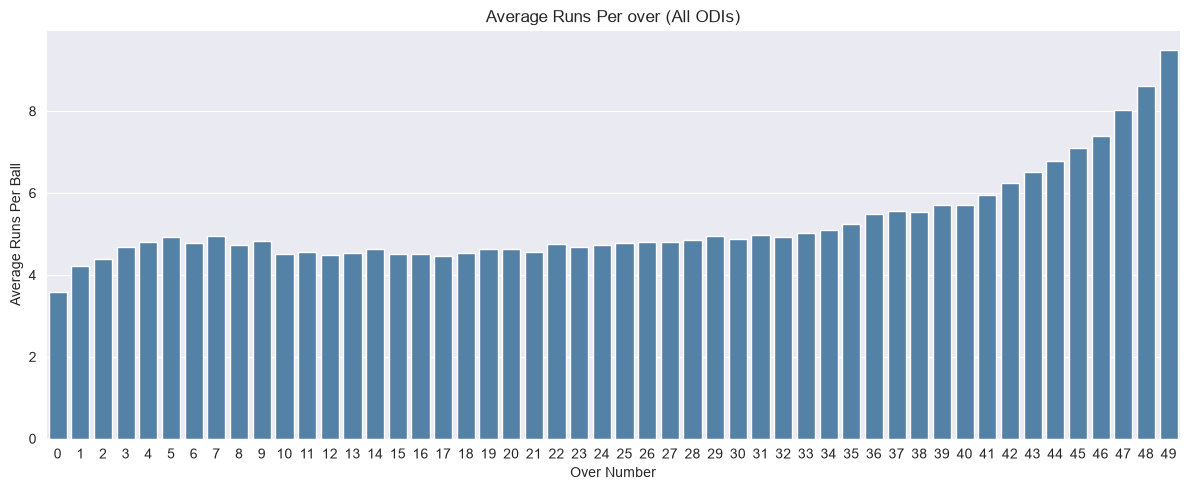

Plot 1 done


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# set style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)
master_df['total_runs'] = (
    master_df['runs_off_bat'].astype(int) +
    master_df['extras'].astype(int)
)
runs_per_over = (
    master_df.groupby('over_num')['total_runs']
    .mean()
    .mul(6)
    .reset_index()
)

plt.figure()
sns.barplot(data=runs_per_over, x='over_num', y='total_runs', color='steelblue')
plt.title('Average Runs Per over (All ODIs)')
plt.xlabel('Over Number')
plt.ylabel('Average Runs Per Ball')
plt.tight_layout()
plt.savefig(r'D:\CricMetric-AI\data\processed\plot_runs_per_over.png')
plt.show()
print("Plot 1 done")

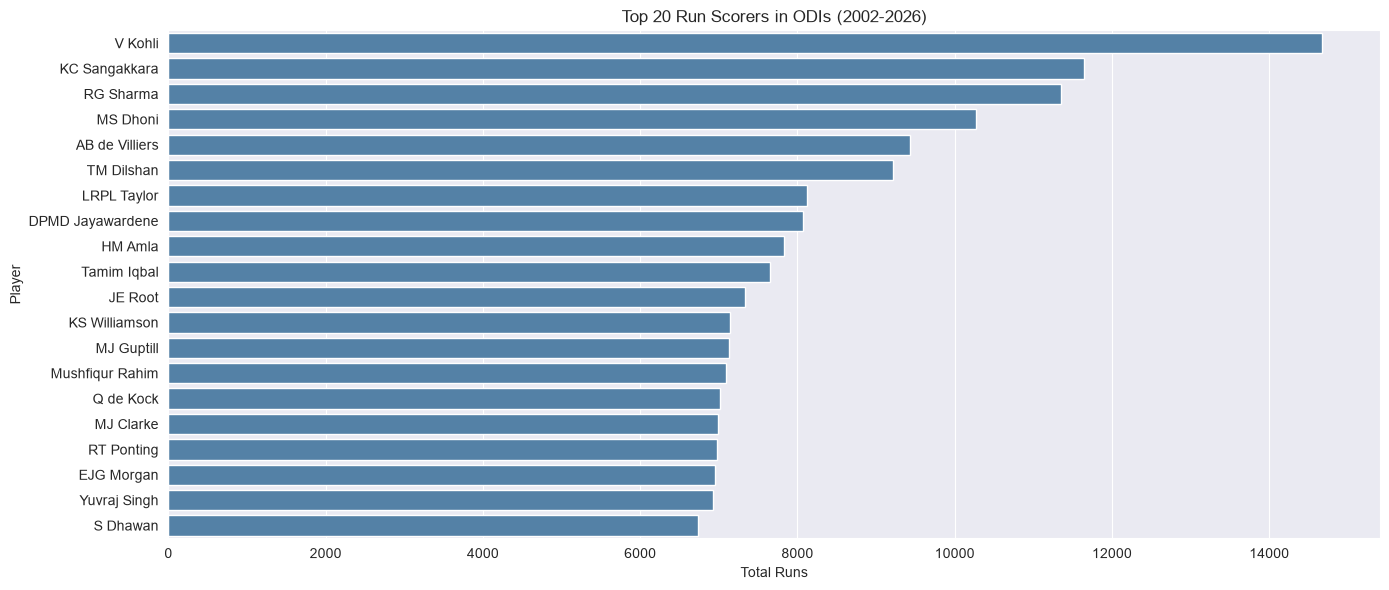

Plot 2 done


In [ ]:
top_batters = master_df.groupby('batter')['runs_off_bat'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(14,6))
sns.barplot(x=top_batters.values, y=top_batters.index, color='steelblue')
plt.title('Top 20 Run Scorers in ODIs (2002-2026)')
plt.xlabel('Total Runs')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig(r'D:\CricMetric-AI\data\processed\plot_top_batters.png')
plt.show()
print("Plot 2 done")

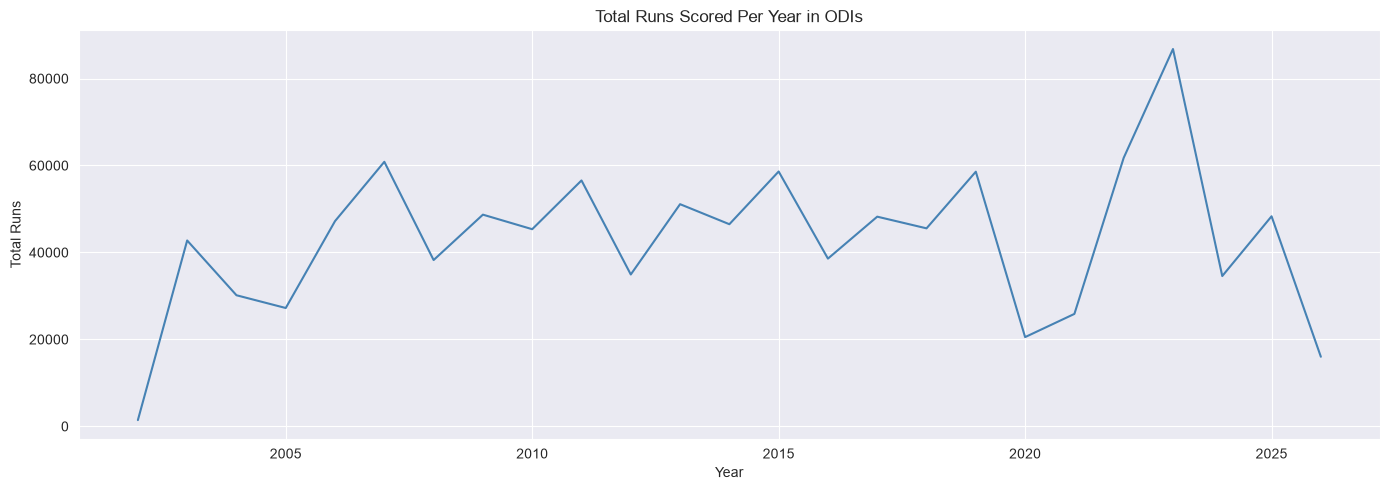

Plot 3 done


In [ ]:
master_df['year'] = master_df['match_date'].str[:4].astype(int)

era_runs = master_df.groupby('year')['runs_off_bat'].sum().reset_index()

plt.figure(figsize=(14,5))
sns.lineplot(data=era_runs, x='year', y='runs_off_bat', color='steelblue')
plt.title('Total Runs Scored Per Year in ODIs')
plt.xlabel('Year')
plt.ylabel('Total Runs')
plt.tight_layout()
plt.savefig(r'D:\CricMetric-AI\data\processed\plot_runs_by_year.png')
plt.show()
print("Plot 3 done")

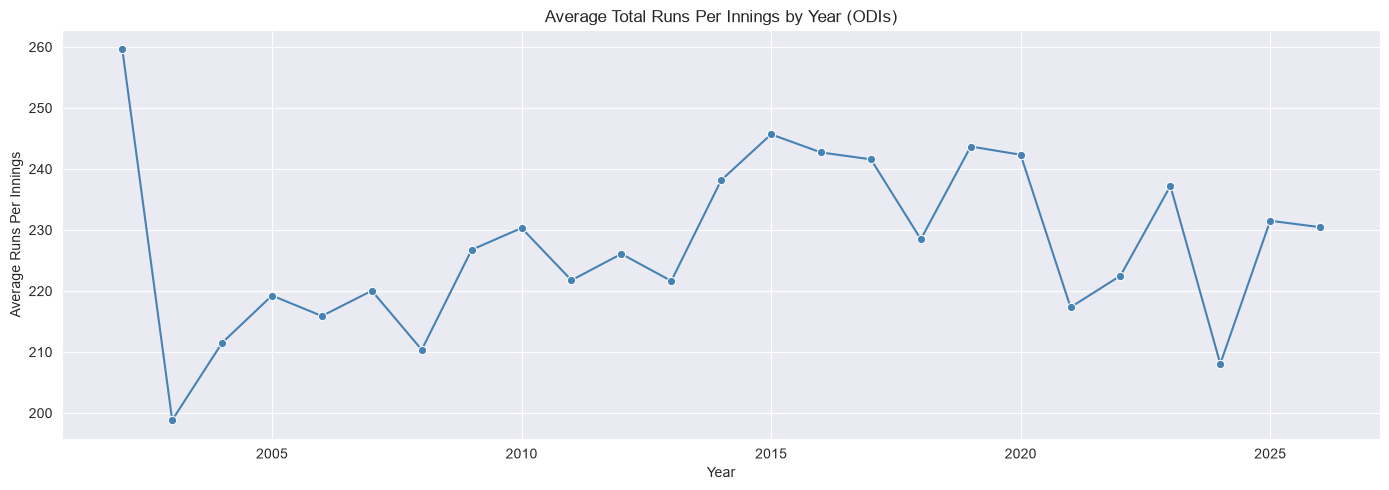

In [ ]:
# Create total runs for every ball
master_df["total_runs"] = (
    master_df["runs_off_bat"].astype(int)
    + master_df["extras"].astype(int)
)

# Total runs in each innings
innings_scores = (
    master_df
    .groupby(["match_id", "innings", "year"])["total_runs"]
    .sum()
    .reset_index()
)

# Average innings score by year
avg_runs_per_innings = (
    innings_scores
    .groupby("year")["total_runs"]
    .mean()
    .reset_index()
)

# Plot
plt.figure(figsize=(14, 5))

sns.lineplot(
    data=avg_runs_per_innings,
    x="year",
    y="total_runs",
    marker="o",
    color="steelblue"
)

plt.title("Average Total Runs Per Innings by Year (ODIs)")
plt.xlabel("Year")
plt.ylabel("Average Runs Per Innings")

plt.tight_layout()
plt.show()

In [ ]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1349408 entries, 0 to 1349407
Data columns (total 34 columns):
 #   Column                  Non-Null Count    Dtype
---  ------                  --------------    -----
 0   innings                 1349408 non-null  str  
 1   over                    1349408 non-null  str  
 2   batting_team            1349408 non-null  str  
 3   batter                  1349408 non-null  str  
 4   non_striker             1349408 non-null  str  
 5   bowler                  1349408 non-null  str  
 6   runs_off_bat            1349408 non-null  int64
 7   extras                  1349408 non-null  int64
 8   wides                   1349408 non-null  int64
 9   noballs                 1349408 non-null  int64
 10  byes                    1349408 non-null  str  
 11  legbyes                 1349408 non-null  str  
 12  penalty                 1349408 non-null  str  
 13  wicket_type             1349408 non-null  str  
 14  player_dismissed        1349408 non-null  str

In [ ]:
master_df.columns.to_list()

['innings',
 'over',
 'batting_team',
 'batter',
 'non_striker',
 'bowler',
 'runs_off_bat',
 'extras',
 'wides',
 'noballs',
 'byes',
 'legbyes',
 'penalty',
 'wicket_type',
 'player_dismissed',
 'other_wicket_type',
 'other_player_dismissed',
 'running_total',
 'extra1',
 'extra2',
 'extra3',
 'match_id',
 'match_date',
 'team1',
 'team2',
 'venue',
 'event',
 'toss_winner',
 'city',
 'season',
 'over_num',
 'ball_num',
 'total_runs',
 'year']

In [ ]:
master_df

,innings,over,batting_team,batter,non_striker,bowler,runs_off_bat,extras,wides,noballs,...,team2,venue,event,toss_winner,city,season,over_num,ball_num,total_runs,year
0,1,0.1,Australia,DA Warner,TM Head,Mohammad Amir,0,0,0,0,...,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,1,0,2017
1,1,0.2,Australia,DA Warner,TM Head,Mohammad Amir,0,0,0,0,...,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,2,0,2017
2,1,0.3,Australia,DA Warner,TM Head,Mohammad Amir,0,0,0,0,...,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,3,0,2017
3,1,0.4,Australia,DA Warner,TM Head,Mohammad Amir,0,0,0,0,...,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,4,0,2017
4,1,0.5,Australia,DA Warner,TM Head,Mohammad Amir,0,1,1,0,...,Pakistan,"Brisbane Cricket Ground, Woolloongabba",Pakistan in Australia ODI Series,Australia,Brisbane,2016/17,0,5,1,2017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1349403,2,46.6,Scotland,PL Mommsen,RD Berrington,Mohammad Shahzad (2),0,0,0,0,...,United Arab Emirates,"Grange Cricket Club Ground, Raeburn Place",ICC World Cricket League Championship,United Arab Emirates,Edinburgh,2016,46,6,0,2016
1349404,2,47.1,Scotland,RD Berrington,PL Mommsen,Rohan Mustafa,0,0,0,0,...,United Arab Emirates,"Grange Cricket Club Ground, Raeburn Place",ICC World Cricket League Championship,United Arab Emirates,Edinburgh,2016,47,1,0,2016
1349405,2,47.2,Scotland,RD Berrington,PL Mommsen,Rohan Mustafa,0,0,0,0,...,United Arab Emirates,"Grange Cricket Club Ground, Raeburn Place",ICC World Cricket League Championship,United Arab Emirates,Edinburgh,2016,47,2,0,2016
1349406,2,47.3,Scotland,RD Berrington,PL Mommsen,Rohan Mustafa,0,0,0,0,...,United Arab Emirates,"Grange Cricket Club Ground, Raeburn Place",ICC World Cricket League Championship,United Arab Emirates,Edinburgh,2016,47,3,0,2016


In [ ]:
tarun_doubt=master_df[master_df['year']==2003].groupby(
    ['match_id', 'innings', 'batting_team']
)['runs_off_bat'].sum().reset_index().copy()

In [ ]:
tarun_doubt[tarun_doubt['runs_off_bat']==27]

,match_id,innings,batting_team,runs_off_bat
95,65249,2,Bangladesh,27


In [ ]:
master_df['event'].value_counts()

event
ICC Men's Cricket World Cup League 2    118084
ICC Cricket World Cup                    69772
ICC World Cup                            51553
NatWest Series                           49675
ICC Champions Trophy                     47032
                                         ...  
Kenya in Canada ODI Series                 305
Kenya in Scotland ODI Series               268
Quadrangular Series (Ireland)              245
TVS Cup (Bangladesh)                       106
Kenya in Ireland ODI Series                 48
Name: count, Length: 283, dtype: int64

In [ ]:
# check what columns have match outcome info
print(master_df.columns.tolist())

# check what 'event' column actually contains
print("\nEvent column sample:")
print(master_df['event'].value_counts().head(20))



['innings', 'over', 'batting_team', 'batter', 'non_striker', 'bowler', 'runs_off_bat', 'extras', 'wides', 'noballs', 'byes', 'legbyes', 'penalty', 'wicket_type', 'player_dismissed', 'other_wicket_type', 'other_player_dismissed', 'running_total', 'extra1', 'extra2', 'extra3', 'match_id', 'match_date', 'team1', 'team2', 'venue', 'event', 'toss_winner', 'city', 'season', 'over_num', 'ball_num', 'total_runs', 'year']

Event column sample:
event
ICC Men's Cricket World Cup League 2            118084
ICC Cricket World Cup                            69772
ICC World Cup                                    51553
NatWest Series                                   49675
ICC Champions Trophy                             47032
Asia Cup                                         31468
VB Series                                        23226
Commonwealth Bank Series                         23153
ICC Cricket World Cup Qualifier                  20794
World Cup                                        19933
Engla

In [ ]:
# check if there's an outcome or result column
for col in master_df.columns:
    if any(word in col.lower() for word in ['result', 'outcome', 'winner', 'method']):
        print(f"\nFound: {col}")
        print(master_df[col].value_counts().head(10))


Found: toss_winner
toss_winner
India           131551
Australia       129632
Sri Lanka       129006
England         117243
Pakistan        116340
South Africa    106430
New Zealand     103329
West Indies      98479
Bangladesh       83058
Zimbabwe         77722
Name: count, dtype: int64


In [ ]:
# check how many matches have no result / are rain affected
no_result = master_df[
    master_df['event'].str.contains('no result|abandoned|rain', 
                                     case=False, na=False)
]['match_id'].nunique()

print(f"Potentially affected matches: {no_result}")



Potentially affected matches: 0
